Gráfico da figura 5.1

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
# saida mais detalhada que LogisticRegression do sklearn.linear_model
# sm.logit usa método de maxima verossimilhança (tradicional) para rodar a logística
#o LogisticRegression usa outro método
from sklearn.metrics import roc_curve, auc,accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef,confusion_matrix
import matplotlib.pyplot as plt

dd=pd.read_excel('/content/sample_data/Grafico5.1.xlsx')
display(dd.head(3))
X=dd['X']
y=dd['prop']
X=np.array(X)
y=np.array(y)
# Treinar o modelo de regressão linear
modelo_linear = LinearRegression()
X_reshape = X.reshape(-1, 1)  # sklearn precisa de array 2D, convert Series to numpy array 2D
modelo_linear.fit(X_reshape, y)
# Fazer predições da reta
y_pred_linear = modelo_linear.predict(X_reshape)

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&

#Gráfico
# Plotar os dados originais
plt.plot(X, y, marker='s',color='blue', linestyle="None",label='Pontos originais',markersize=4)
# Plotar a curva ajustada com linha pontilhada
plt.plot(X, y_pred_linear, linestyle='--', color='red', label=f'Reta ajustada')
# Adiciona uma reta horizontal em y = 14
plt.axhline(y=1, color='black', linestyle='solid' )

# Adicionar legenda e mostrar
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
#plt.grid(True, color="lightgrey")
plt.show()

Código 5.1: Análise e preparação da base de dados TECAL (resultados no Apendice A do Capítulo 5)

In [ ]:
#Código 5.1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

tec=pd.read_excel('/content/sample_data/TECAL.xlsx')
display(tec.head(3))

####################################################################
# análise de "cancel" (variável alvo)
frequency_table = tec['cancel'].value_counts()
print("Tabela de Frequência de cancel:")
print(frequency_table)
proportion_table = tec['cancel'].value_counts(normalize=True)
print("\nTabela de Proporção de cancel:")
formatted_series = proportion_table.map(lambda x: f"{x:.2f}")
print(formatted_series)

####################################################################
#análise de "idade"
variavel = tec['idade']
summary = {
    'n_total': len(variavel),
    'n_missing': variavel.isna().sum(),
    'mean': variavel.mean(),
    'std': variavel.std(),
    'min': variavel.min(),
    '25%': variavel.quantile(0.25),
    '50% (mediana)': variavel.median(),
    '75%': variavel.quantile(0.75),
    'max': variavel.max()
}
print("\nResumo da variável 'idade':")
summary_series = pd.Series(summary)
formatted_series = summary_series.map(lambda x: f"{x:.2f}")
print(formatted_series)

variavel = tec['idade']
plt.figure(figsize=(12, 5))  # Define o tamanho da figura
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(variavel, color='lightgrey', bins=15)
plt.title('Histograma de idade')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['idade'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de idade por cancel')
plt.tight_layout()
plt.show()

####################################################################
#variavel "linhas"
# Criando a tabela cruzada entre linhas e cancel
cross_tab = pd.crosstab(tec['linhas'], tec['cancel'])
print("\nTabela Cruzada de Frequências entre linhas e cancel:")
print(cross_tab)

# Calculando as proporções em relação ao total de cada linha
cross_tab_prop_linha = pd.crosstab(tec['linhas'], tec['cancel'], normalize='index')
print("\nTabela Cruzada de Proporções por linha entre linhas e cancel:")
formatted_tab = cross_tab_prop_linha.map(lambda x: f"{x:.2f}")
print(formatted_tab)

####################################################################
#variável temp_cli
variavel = tec['temp_cli']
summary = {
    'n_total': len(variavel),
    'n_missing': variavel.isna().sum(),
    'mean': variavel.mean(),
    'std': variavel.std(),
    'min': variavel.min(),
    '25%': variavel.quantile(0.25),
    '50% (mediana)': variavel.median(),
    '75%': variavel.quantile(0.75),
    'max': variavel.max()
}
print("\nResumo da variável 'temp_cli':")
summary_series = pd.Series(summary)
formatted_series = summary_series.map(lambda x: f"{x:.2f}")
print(formatted_series)

variavel = tec['temp_cli']
plt.figure(figsize=(12, 5))  # Define o tamanho da figura
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(variavel, color='lightgrey', bins=15)
plt.title('Histograma de temp_cli')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['temp_cli'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de temp_cli por cancel')
plt.tight_layout()
plt.show()

#removendo outliers
tec = tec[~((tec['cancel'] == 'sim') & (tec['temp_cli'] >40))]
print("\nDataFrame após remover outliers de 'temp_cli':")
print(tec.head(3))
plt.figure(figsize=(12, 5))  # Define o tamanho da figura
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(tec['temp_cli'], color='lightgrey', bins=15)
plt.title('Histograma de temp_cli')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['temp_cli'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de temp_cli por cancel')
plt.tight_layout()
plt.show()

####################################################################
#variável renda
variavel = tec['renda']
summary = {
    'n_total': len(variavel),
    'n_missing': variavel.isna().sum(), #informação importante
    'mean': variavel.mean(),
    'std': variavel.std(),
    'min': variavel.min(),
    '25%': variavel.quantile(0.25),
    '50% (mediana)': variavel.median(),
    '75%': variavel.quantile(0.75),
    'max': variavel.max()
}
print("\nResumo da variável 'renda':")
summary_series = pd.Series(summary)
formatted_series = summary_series.map(lambda x: f"{x:.2f}")
print(formatted_series)

variavel = tec['renda']
plt.figure(figsize=(12, 5))  # Define o tamanho da figura
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(variavel, color='lightgrey', bins=15)
plt.title('Histograma de renda')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['renda'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de renda por cancel')
plt.tight_layout()
plt.show()

#transformação Box-Cox
rendabc, lambda_ = stats.boxcox(tec['renda'])
print(f'\nLambda calculado para renda pela função: {lambda_:.5f}')
# arredondando lambda para facilitar futuras transformações
rendabc=(tec["renda"]**(-1.54) -1)/(-1.54)
print(f'Lambda utilizado para renda: {-1.54}')
pd.set_option('display.float_format', '{:.8f}'.format)
rendabc=pd.DataFrame(rendabc)
print(f"minimo de rendabc: {rendabc.min():}")
print(f"maximo de rendabc: {rendabc.max()}")
rendabc=(rendabc-0.64934)*10000000
#transformação para controlar ordem de grandeza (opcional, porem facilita leitura)
pd.set_option('display.float_format', '{:.3f}'.format)
print(f"minimo de rendabc escalonado: {rendabc.min():}")
print(f"maximo de rendabc escalonado: {rendabc.max()}")

#inserindo no arquivo de trabalho:
tec["renda_bc"] = rendabc
print(" missing values" ,tec.isnull().sum())
#pd.set_option('display.float_format', '{:.4f}'.format)
df=pd.DataFrame({"renda":tec["renda"],"renda_bc":tec["renda_bc"]})
print("\nComparação entre renda original e renda_bc:")
print(df.head(5))
# grafando a variável transformada
plt.figure(figsize=(12, 5))  # Define o tamanho da figura
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(tec["renda_bc"],hue=None, color='lightgrey', bins=15, edgecolor='black')
plt.title('Histograma de renda_bc')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec["renda_bc"], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de renda_bc por cancel')
plt.tight_layout()
plt.show()

####################################################################
#Variável fatura
variavel = tec['fatura']
summary = {
    'n_total': len(variavel),
    'n_missing': variavel.isna().sum(), #informação importante
    'mean': variavel.mean(),
    'std': variavel.std(),
    'min': variavel.min(),
    '25%': variavel.quantile(0.25),
    '50% (mediana)': variavel.median(),
    '75%': variavel.quantile(0.75),
    'max': variavel.max()
}
print("\nResumo da variável 'fatura':")
tec["fatura"].describe(include=None)
summary_series = pd.Series(summary)
formatted_series = summary_series.map(lambda x: f"{x:.2f}")
print(formatted_series)

plt.figure(figsize=(12, 5))
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(tec['fatura'], color='lightgrey', bins=15)
plt.title('Histograma de fatura')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['fatura'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de fatura por cancel')
plt.tight_layout()
plt.show()

#transformação Box-Cox
from scipy import stats
faturabc, lambda_ = stats.boxcox(tec['fatura'])
print(f'\nLambda calculado para fatura pela função: {lambda_:.5f}')
print(f'Lambda utilizado para fatura: {0.2}')
# arredondando lambda para simplificar futuras transformações
faturabc=(tec["fatura"]**0.2 -1)/0.2
pd.set_option('display.float_format', '{:.8f}'.format)
faturabc=pd.DataFrame(faturabc)
print(f"minimo de fatura_bc: {faturabc.min():}")
print(f"maximo de fatura_bc: {faturabc.max()}")
tec["fatura_bc"]= faturabc
print(" missing values" ,tec.isnull().sum())

#pd.set_option('display.float_format', '{:.3f}'.format)
df=pd.DataFrame({"fatura":tec["fatura"],"faturabc":tec["fatura_bc"]})
print("\nComparação entre fatura original e fatura_bc:")
print(df.head(5))
# grafando a variável transformada
plt.figure(figsize=(10, 5))
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(tec["fatura_bc"],hue=None, color='lightgrey', bins=15, edgecolor='black')
plt.title('Histograma de fatura_bc')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec["fatura_bc"], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de fatura_bc por cancel')
plt.tight_layout()
plt.show()

####################################################################
#Variável : temp_rsd
variavel = tec['temp_rsd']
summary = {
    'n_total': len(variavel),
    'n_missing': variavel.isna().sum(), #informação importante
    'mean': variavel.mean(),
    'std': variavel.std(),
    'min': variavel.min(),
    '25%': variavel.quantile(0.25),
    '50% (mediana)': variavel.median(),
    '75%': variavel.quantile(0.75),
    'max': variavel.max()
}
print("\nResumo da variável 'temp_rsd':")
summary_series = pd.Series(summary)
formatted_series = summary_series.map(lambda x: f"{x:.2f}")
print(formatted_series)

plt.figure(figsize=(12, 5))
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(tec['temp_rsd'], color='lightgrey', bins=15)
plt.title('Histograma de temp_rsd')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['temp_rsd'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de tmp_rsd por cancel')
plt.tight_layout()
plt.show()

#removendo outliers
tec = tec[~((tec['cancel'] == 'nao') & (tec['temp_rsd'] > 12))]
print("\nDataFrame após remover outliers de 'temp_rsd':")
print(tec.head(3))
plt.figure(figsize=(12, 5))
# Histograma
plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, primeiro gráfico
sns.histplot(tec['temp_rsd'] , color='lightgrey', bins=15)
plt.title('Histograma de temp_rsd')
# Boxplot
plt.subplot(1, 2, 2)  # Segundo gráfico
sns.boxplot(data=tec, x=tec['temp_rsd'], y=tec['cancel'], color='lightgrey')
plt.title('Boxplot de temp_rsdpor cancel')
plt.tight_layout()
plt.show()

################################################################################
#variavel "local"
# Criando a tabela cruzada entre local e cancel
cross_tab = pd.crosstab(tec['local'], tec['cancel'])
print("\nTabela Cruzada de Frequências entre local e cancel:")
print(cross_tab)

# Calculando as proporções em relação ao total de cada linha
cross_tab_prop_linha = pd.crosstab(tec['local'], tec['cancel'], normalize='index')
print("\nTabela Cruzada de Proporções por linha entre local e cancel:")
formatted_tab = cross_tab_prop_linha.map(lambda x: f"{x:.2f}")
print(formatted_tab)


###############################################################################
#variavel "tvcabo"
# Criando a tabela cruzada entre tvcabo e cancel
cross_tab = pd.crosstab(tec['tvcabo'], tec['cancel'])
print("\nTabela Cruzada de Frequências entre tvcabo e cancel:")
print(cross_tab)

# Calculando as proporções em relação ao total de cada linha
cross_tab_prop_linha = pd.crosstab(tec['tvcabo'], tec['cancel'], normalize='index')
print("\nTabela Cruzada de Proporções por linha entre tvcabo e cancel:")
formatted_tab = cross_tab_prop_linha.map(lambda x: f"{x:.2f}")
print(formatted_tab)
################################################################################
#variavel "debaut"
# Criando a tabela cruzada entre debaut e cancel
cross_tab = pd.crosstab(tec['debaut'], tec['cancel'])
print("Tabela Cruzada de Frequências entre debaut e cancel:")
print(cross_tab)

# Calculando as proporções em relação ao total de cada linha
cross_tab_prop_linha = pd.crosstab(tec['debaut'], tec['cancel'], normalize='index')
print("\nTabela Cruzada de Proporções por linha entre debaut e cancel:")
formatted_tab = cross_tab_prop_linha.map(lambda x: f"{x:.2f}")
# Formata como string com 2 casas visíveis
print(formatted_tab)

###############################################################################
#gerando um novo dataframe contendo apenas as variáveis de trabalho
print("\nDataFrame original:")
print(tec.head(2))
print(tec.shape)
tecx=tec.copy()
tecx = tecx.drop(columns=['renda', 'fatura'])
print("\nNovo DataFrame 'tecx' sem as colunas 'renda' e 'fatura':")
print(tecx.head(2))
print(tecx.shape)
tecx.to_excel('TECAL_MOD.xlsx')
#salvaremos em Excel deletando a primeira coluna gerada pelo Python (inutil)
tecx.isnull().sum()
print(" missing values em TECAL_MOD" ,tecx.isnull().sum())

Código 5.2: Gerar amostra de aprendizado (train) e amostra teste (test)


In [122]:
#Código 5.2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

tecmod=pd.read_excel('/content/sample_data/TECAL_MOD.xlsx')
display(tecmod.head(3))
print(tecmod.shape)
X= tecmod.drop('cancel', axis=1)
print(X.columns)
y= tecmod['cancel']
y=pd.DataFrame(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,        # 50% para teste
    random_state=5,       # para reprodutibilidade (valor arbitrário)
    stratify=y            # estratificação com base na variável y
)
print(X_train.head(5))
print(y_train.head(5))
print(type(y_train))
# Verificar os tamanhos das amostras e as proporções de cancel
print("\nTamanho do conjunto de treinamento:", X_train.shape[0])
print("\nTamanho do conjunto de teste:", X_test.shape[0])
frequencia_train = y_train['cancel'].value_counts(normalize=True,dropna=False).sort_index()
frequencia_test = y_test['cancel'].value_counts(normalize=True,dropna=False).sort_index()
formatted_tab = frequencia_train .map(lambda x: f"{x:.3f}")  # Formata como string com 2 casas visíveis
print(f"\nFrequência de cancel em X_train:\n {formatted_tab}")
formatted_test = frequencia_test .map(lambda x: f"{x:.3f}")  # Formata como string com 2 casas visíveis
print(f"\nFrequência de cancel em X_test:\n {formatted_test}")

,Unnamed: 0,id,idade,linhas,temp_cli,temp_rsd,local,tvcabo,debaut,cancel,renda_bc,fatura_bc
0,0,TC-0001,51,3,26,7.30000000,A,sim,nao,nao,94.62009921,12.61691952
1,1,TC-0002,36,2,16,4.50000000,A,sim,nao,nao,95.58198398,12.20201856
2,2,TC-0003,35,1,15,4.80000000,A,nao,nao,nao,92.84580784,12.93002698


(1995, 12)
Index(['Unnamed: 0', 'id', 'idade', 'linhas', 'temp_cli', 'temp_rsd', 'local',
       'tvcabo', 'debaut', 'renda_bc', 'fatura_bc'],
      dtype='object')
      Unnamed: 0       id  idade  linhas  temp_cli   temp_rsd local tvcabo  \
399          399  TC-0400     36       2        20 4.90000000     D    sim   
1311        1315  TC-1316     45       3        20 7.40000000     A    sim   
1098        1102  TC-1103     35       1        28 5.80000000     C    sim   
1227        1231  TC-1232     39       1        13 6.60000000     D    sim   
127          127  TC-0128     38       1        22 4.20000000     C    sim   

     debaut     renda_bc   fatura_bc  
399     nao  94.75627952 11.17225784  
1311    nao 103.05239120 15.27365796  
1098    nao 102.80705806 13.51364161  
1227    nao  95.14974154  8.93259011  
127     nao  93.42982833 13.26779806  
     cancel
399     nao
1311    nao
1098    nao
1227    nao
127     nao
<class 'pandas.core.frame.DataFrame'>

Tamanho do conjunto d

Código 5.3: Regressao logística e seleção de variáveis com backward selection

In [124]:
# Código 5.3:  Regressao Logística utilizando Backward Selection

#XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
#CUIDADO: ao rodar esta célula (ou eventualmente, parte dela)
#   o analista deverá rodar antes código 5.1 em diante
#   pois os arquivos X_train, X_test, y_train, y_test podem ter sido modificados
#XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc,accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef,confusion_matrix
import matplotlib.pyplot as plt

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
#preparação dos dados de entrada

# converter y em (0s e 1s)
print("Dim. de y_train:", y_train.shape)
y_train = y_train['cancel'].map({'nao': 0, 'sim': 1})
y_test = y_test['cancel'].map({'nao': 0, 'sim': 1})
print(y_train.head(5))
print(y_test.head(5))
print("TIPO de y_train:", type(y_train))
print("TIPO de y_test:", type(y_test))
#Drop "id"
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])
#transforma em dummies
# One-hot encode categorical variables
X_train = pd.get_dummies(X_train, columns=['local', 'tvcabo', 'debaut'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['local', 'tvcabo', 'debaut'], drop_first=True)
# Converter true false em  (0s e 1s)
for col in X_train.columns:
    if X_train[col].dtype == 'bool':
        X_train[col] = X_train[col].astype(int)
for col in X_test.columns:
    if X_test[col].dtype == 'bool':
        X_test[col] = X_test[col].astype(int)
#eliminar  coluna Unnamed:0
X_train = X_train.drop(columns=['Unnamed: 0'])
X_test = X_test.drop(columns=['Unnamed: 0'])

# Ensure that X_test has the same columns as X_train after one-hot encoding
# This is important if one-hot encoding results in different columns due to varying categories
#missing_cols = set(X_train.columns) - set(X_test.columns)
#for c in missing_cols:
#    X_test[c] = 0
#X_test = X_test[X_train.columns]

# Add a constant to X_train and X_test for statsmodels (required)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
print("\n X_train",X_train.head(3))
print("\n X_test",X_test.head(3))

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&

#rodando e selecionando as variáveis
def backward_elimination(X_train, y_train, significance_level=0.15):
    # Ajustando o modelo de regressão logística
    model = sm.Logit(y_train, X_train)
    result = model.fit(disp=False) # suppress convergence output

    # Mostrando o resumo  do modelo com todas as preditoras
    print("Resumo do modelo inicial:")
    print(result.summary())

    # Realizando a eliminação backward
    while True:
        p_values = result.pvalues

        # Identify the variable with the highest p-value, excluding the constant
        if 'const' in p_values:
            p_values_excl_const = p_values.drop('const')
        else:
            p_values_excl_const = p_values

        if p_values_excl_const.empty: # Stop if no more variables to drop
            break

        max_p_value = p_values_excl_const.max()
        worst_feature = p_values_excl_const.idxmax()


        # Check criterion for stopping
        if max_p_value > significance_level:
            # Remover a variável com o maior p-valor
            print(f"\nRemovendo a variável: {worst_feature} com p-valor: {max_p_value:.4f}")
            X_train = X_train.drop(columns=[worst_feature])

            # Ajustando o modelo novamente com as variáveis restantes
            model = sm.Logit(y_train, X_train)
            result = model.fit(disp=False) # suppress convergence output
        else:
            print("\nCritério de parada atingido. Modelo final selecionado.")
            break

    # Resumo final do modelo após a eliminação
    print("\nResumo final após backward elimination:")
    print(result.summary())

    return result, X_train
#cuidado: result só existe dentro da função. Nao é valor salvo
#===============================================================================
# Executando a eliminação backward com a amostra de treinamento
final_model, X_selected = backward_elimination(X_train, y_train)
# O modelo final está em final_model, e as variáveis selecionadas em X_selected
print("\nSelected features:", X_selected.columns.tolist())
#===============================================================================
# selecting columns in X_test to be the same as X_selected
selected_columns = X_selected.columns
# Filter X_test using selected_columns
X_test = X_test[selected_columns]


#===============================================================================
#Previsões das probabilidades de mau pagador
y_pred_prob = final_model.predict(X_test)
print("\n probs. previstas\n",y_pred_prob.head(3))

#===============================================================================
# gerando um arquivo com todas as colunas de X_test usadas no modelo
# e as probabilidade prevista de ser mau pagador y_pred_prob ==> X_FINAL
X_FINAL=X_test.copy()
X_FINAL['y_pred_prob'] = y_pred_prob
# Exibindo o DataFrame atualizado
print(X_FINAL.head(3))

#===============================================================================
#Teste de Hosmer Lemeshow utlizando pandas
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from scipy.stats import chi2

print(y_train.head(5))
print(X_FINAL["y_pred_prob"].head(5))

y_true=y_test
y_prob=X_FINAL["y_pred_prob"]

# Função para o teste de Hosmer-Lemeshow
def hosmer_lemeshow_test(y_true, y_prob, g=8):
    data = pd.DataFrame({'y': y_true, 'prob': y_prob})
    data['quantile'] = pd.qcut(data['prob'], g, duplicates='drop')

    obs = data.groupby('quantile', observed=False)['y'].sum()
    exp = data.groupby('quantile', observed=False)['prob'].sum()
    total = data.groupby('quantile', observed=False)['y'].count()
    not_obs = total - obs
    not_exp = data.groupby('quantile', observed=False)['prob'].apply(lambda x: (1 - x).sum())

    hl_stat = (((obs - exp) ** 2) / (exp + 1e-10) + ((not_obs - not_exp) ** 2) / (not_exp + 1e-10)).sum()
    dof = g - 2
    p_value = 1 - chi2.cdf(hl_stat, dof)

    return hl_stat, p_value

# Aplicar o teste
hl_stat, p_value = hosmer_lemeshow_test(y_true, y_prob)
print(f"Hosmer-Lemeshow Statistic: {hl_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
#===============================================================================
#Teste de SPIEGELHALTER

from scipy.stats import norm
from sklearn.metrics import brier_score_loss

# Calculando o Brier Score para o modelo
bs= brier_score_loss(y_test, y_pred_prob)
print(f'Brier Score do modelo utilizado: {bs:.4f}')

#estatística do teste
EBS=(y_pred_prob*(1-y_pred_prob)).sum()/len(y_pred_prob)
DPBS=np.sqrt(((1-2*y_pred_prob)**2*y_pred_prob*(1-y_pred_prob)).sum())/len(y_pred_prob)
z=(bs-EBS)/DPBS
pval=2*norm.cdf(-abs(z))
print(f"p-value spiegelhater modelo utilizado: {pval:.4f}")
print("\n\n")


 probs. prevista
 82     0.76870130
1928   0.00830405
1208   0.00332221
dtype: float64


Código 5.4: Avaliação do modelo de classificação

frequencia de bons (0) e maus (1) pagadores cancel
0   0.76252505
1   0.23747495
Name: proportion, dtype: float64

Resultados para ponto de corte PC= 0.6

Acurácia: 0.834

Precisão: 0.735

Recall: 0.468

F1-score: 0.572

Mathews correlation coeficient: 0.494

Matriz de Classificação:

                 Classe predita: 0  Classe predita: 1
Classe real: 0                721                 40
Classe real: 1                126                111


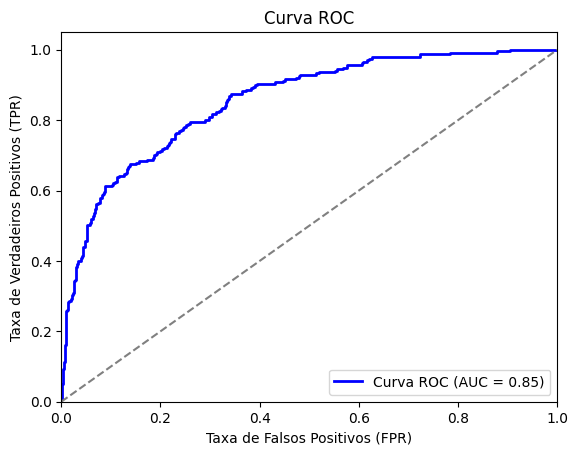

AUC: 0.85


In [125]:
#Código 5.4
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc,accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef,confusion_matrix
import matplotlib.pyplot as plt
#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
# Avaliação do modelo para um ponto de corte PC
PC=0.6
y_pred = (y_pred_prob >= PC).astype(int)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
MCC=matthews_corrcoef(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Correct the column name 'STATUS_MP' to 'cancel' for value_counts
frequencia_test = y_test.value_counts(normalize=True).sort_index()
print("frequencia de bons (0) e maus (1) pagadores",frequencia_test)
print(f"\nResultados para ponto de corte PC= {PC}")
print(f"\nAcurácia: {accuracy:.3f}")
print(f"\nPrecisão: {precision:.3f}")
print(f"\nRecall: {recall:.3f}")
print(f"\nF1-score: {f1:.3f}")
print(f"\nMathews correlation coeficient: {MCC:.3f}")
print("\nMatriz de Classificação:")

matriz = np.array(conf_matrix)
# Criando um DataFrame com nomes de linhas e colunas
df = pd.DataFrame(
    matriz,
    index=["Classe real: 0", "Classe real: 1"],
    columns=["Classe predita: 0", "Classe predita: 1"]
)
# Imprimindo
print("\n",df)

#===============================================================================
# Calcular a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
# Calcular a AUC (Área sob a Curva)
roc_auc = auc(fpr, tpr)
# Plotar a curva ROC
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()
# Exibir a AUC
print(f'AUC: {roc_auc:.2f}')
#===============================================================================

Código 5.5 Geração das classes de risco

In [127]:
#código 5.5

#XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
#CUIDADO: ao rodar esta célula (ou eventualmente, parte dela)
#   o analista deverá rodar antes as células anteriores (5.1 em diante)
#   pois os arquivos X_train, X_test, y_train, y_test podem ter sido modificados
#XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX


# Dividir a probabilidade y_pred_prob em 5 classes de mesma frequência
classes, bins = pd.qcut(X_FINAL['y_pred_prob'], 5, retbins=True)
# Adiciona as classes com os limites no arquivo X_FINAL
PMP_CLASS = pd.cut(X_FINAL['y_pred_prob'], bins, include_lowest=True, labels=[f'{bins[i]:.3f} - {bins[i+1]:.3f}' for i in range(len(bins)-1)])
df = pd.DataFrame({
    'cancel': y_test,
    'y_pred_prob': y_pred_prob
})
df['cancel'] = df['cancel'].map({0: 'nao', 1: 'sim'})
print(df.head(3))

bins = [0, 0.25, 0.50, 0.75,  1]  # 5 intervalos definidos pelo analista
PMP_CLASS = pd.cut(X_FINAL['y_pred_prob'], bins, include_lowest=True, labels=[f'{bins[i]:.3f} - {bins[i+1]:.3f}' for i in range(len(bins)-1)])
distribuicao = df.groupby(PMP_CLASS, observed=True)['cancel'].value_counts(normalize=True).unstack(fill_value=0)
# Mostrar a tabela
distribuicao.columns = ['cancel=nao', 'cancel=sim']
distribuicao['sim/nao'] = distribuicao['cancel=sim'] / distribuicao['cancel=nao'].replace(0, 1)  # Substituir 0 por 1 para evitar divisão por zero
print("\nClasses de risco" )
print(distribuicao.round(3))


     cancel  y_pred_prob
82      nao   0.76870130
1928    nao   0.00830405
1208    nao   0.00332221

Classes de risco
               cancel=nao  cancel=sim    sim/nao
y_pred_prob                                     
0.000 - 0.250  0.91200000  0.08800000 0.09600000
0.250 - 0.500  0.73200000  0.26800000 0.36500000
0.500 - 0.750  0.39800000  0.60200000 1.51100000
0.750 - 1.000  0.19300000  0.80700000 4.17600000
